# 📊 Student Performance Analysis
**Cognevance Technologies — Data Science & Data Analytics (Level 1)**
**Author:** Roshni Kumari

Full workflow: data quality → cleaning → feature engineering → EDA →
statistical analysis → segmentation → risk analysis → findings.

**Note on data:** this notebook runs on a synthetically generated dataset
built to match the schema of public Kaggle student-performance datasets.
All results describe patterns within this dataset only; see Section 9
(Limitations) for details.


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Load the Dataset

In [2]:
df_raw = pd.read_csv("data/student_data.csv")
df_raw.head()


,student_id,gender,parental_education,lunch,test_preparation,attendance_percentage,study_hours_per_week,math_score,reading_score,writing_score
0,S1000,male,associate's degree,standard,none,84.6,4.9,35.0,34.4,35.0
1,S1001,female,bachelor's degree,standard,none,92.2,5.2,61.5,55.2,60.1
2,S1002,female,some college,standard,none,80.4,3.1,41.2,41.3,39.9
3,S1003,male,high school,standard,none,76.2,5.6,48.7,49.8,46.5
4,S1004,male,high school,standard,completed,59.2,6.0,52.7,56.4,54.0


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             502 non-null    str    
 1   gender                 502 non-null    str    
 2   parental_education     502 non-null    str    
 3   lunch                  502 non-null    str    
 4   test_preparation       502 non-null    str    
 5   attendance_percentage  497 non-null    float64
 6   study_hours_per_week   502 non-null    float64
 7   math_score             497 non-null    float64
 8   reading_score          502 non-null    float64
 9   writing_score          502 non-null    float64
dtypes: float64(5), str(5)
memory usage: 39.3 KB


## 3. Data Quality Check

In [4]:
print("Missing values:\n", df_raw.isna().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())
print("Duplicate student IDs:", df_raw["student_id"].duplicated().sum())


Missing values:
 student_id               0
gender                   0
parental_education       0
lunch                    0
test_preparation         0
attendance_percentage    5
study_hours_per_week     0
math_score               5
reading_score            0
writing_score            0
dtype: int64

Duplicate rows: 2
Duplicate student IDs: 2


## 4. Data Cleaning & Feature Engineering
Steps: remove duplicates, impute missing numeric values with the median,
clip out-of-range values, normalize categorical text, and engineer
`average_score`, `grade`, and `attendance_band`.


In [5]:
df = df_raw.drop_duplicates().drop_duplicates(subset="student_id", keep="first")

numeric_cols = ["attendance_percentage", "study_hours_per_week",
                 "math_score", "reading_score", "writing_score"]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df["attendance_percentage"] = df["attendance_percentage"].clip(0, 100)
for col in ["math_score", "reading_score", "writing_score"]:
    df[col] = df[col].clip(0, 100)

for col in ["gender", "parental_education", "lunch", "test_preparation"]:
    df[col] = df[col].str.strip().str.lower()

df["average_score"] = df[["math_score", "reading_score", "writing_score"]].mean(axis=1).round(1)

def grade(score):
    if score >= 90: return "A"
    elif score >= 75: return "B"
    elif score >= 60: return "C"
    elif score >= 40: return "D"
    return "F"

df["grade"] = df["average_score"].apply(grade)

def attendance_band(pct):
    if pct >= 90: return "Excellent (90-100%)"
    elif pct >= 75: return "Good (75-89%)"
    elif pct >= 60: return "Average (60-74%)"
    return "Low (<60%)"

df["attendance_band"] = df["attendance_percentage"].apply(attendance_band)

df = df.reset_index(drop=True)
print(f"Cleaned dataset: {len(df)} rows, {df.shape[1]} columns")
df.head()


Cleaned dataset: 500 rows, 13 columns


,student_id,gender,parental_education,lunch,test_preparation,attendance_percentage,study_hours_per_week,math_score,reading_score,writing_score,average_score,grade,attendance_band
0,S1000,male,associate's degree,standard,none,84.6,4.9,35.0,34.4,35.0,34.8,F,Good (75-89%)
1,S1001,female,bachelor's degree,standard,none,92.2,5.2,61.5,55.2,60.1,58.9,D,Excellent (90-100%)
2,S1002,female,some college,standard,none,80.4,3.1,41.2,41.3,39.9,40.8,D,Good (75-89%)
3,S1003,male,high school,standard,none,76.2,5.6,48.7,49.8,46.5,48.3,D,Good (75-89%)
4,S1004,male,high school,standard,completed,59.2,6.0,52.7,56.4,54.0,54.4,D,Low (<60%)


In [6]:
df.to_csv("data/student_data_clean.csv", index=False)


## 5. Exploratory Data Analysis

### 5.1 Descriptive Statistics

In [7]:
num_cols = ["attendance_percentage", "study_hours_per_week",
            "math_score", "reading_score", "writing_score", "average_score"]
desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew()
desc.round(2)


,count,mean,std,min,25%,50%,75%,max,skew
attendance_percentage,500.0,80.94,9.27,51.5,74.57,81.70,87.50,100.0,-0.18
study_hours_per_week,500.0,4.10,2.03,0.0,2.70,4.10,5.60,9.5,-0.03
math_score,500.0,48.32,11.16,9.8,41.00,48.60,55.52,78.8,-0.13
reading_score,500.0,48.80,11.54,12.4,40.68,48.90,56.12,88.0,0.16
writing_score,500.0,48.05,11.32,2.3,39.90,48.05,55.35,81.4,-0.02
average_score,500.0,48.39,10.56,9.3,40.80,48.55,55.00,80.5,0.01


### 5.2 Correlation Analysis
Pearson (linear) and Spearman (monotonic, rank-based) correlation between
`average_score` and each numeric predictor, each with its p-value.


In [8]:
for col in ["attendance_percentage", "study_hours_per_week"]:
    pearson_r, pearson_p = stats.pearsonr(df[col], df["average_score"])
    spearman_r, spearman_p = stats.spearmanr(df[col], df["average_score"])
    print(f"{col}:")
    print(f"  Pearson  r = {pearson_r:.3f}, p = {pearson_p:.2e}")
    print(f"  Spearman r = {spearman_r:.3f}, p = {spearman_p:.2e}")


attendance_percentage:
  Pearson  r = 0.414, p = 3.87e-22
  Spearman r = 0.385, p = 4.27e-19
study_hours_per_week:
  Pearson  r = 0.515, p = 3.68e-35
  Spearman r = 0.496, p = 2.02e-32


### 5.3 Simple Linear Regression
Ordinary least-squares regression of `average_score` on each variable
individually. These are single-variable, descriptive fits — not
predictive or causal models.


In [9]:
for predictor in ["attendance_percentage", "study_hours_per_week"]:
    slope, intercept, r_value, p_value, std_err = stats.linregress(df[predictor], df["average_score"])
    print(f"average_score ~ {predictor}")
    print(f"  slope={slope:.4f}  intercept={intercept:.3f}  R^2={r_value**2:.4f}  p={p_value:.2e}")


average_score ~ attendance_percentage
  slope=0.4718  intercept=10.204  R^2=0.1715  p=3.87e-22
average_score ~ study_hours_per_week
  slope=2.6776  intercept=37.412  R^2=0.2649  p=3.68e-35


### 5.4 Group-wise Analysis

In [10]:
by_gender = df.groupby("gender")["average_score"].agg(["mean","std","count"]).round(2)
by_prep = df.groupby("test_preparation")["average_score"].agg(["mean","std","count"]).round(2)
by_band = df.groupby("attendance_band")["average_score"].agg(["mean","std","count"]).round(2)
by_parent_edu = df.groupby("parental_education")["average_score"].agg(["mean","std","count"]).round(2)

prep_completed = df.loc[df["test_preparation"]=="completed", "average_score"]
prep_none = df.loc[df["test_preparation"]=="none", "average_score"]
t_stat, t_p = stats.ttest_ind(prep_completed, prep_none, equal_var=False)

edu_groups = [g["average_score"].values for _, g in df.groupby("parental_education")]
anova_f, anova_p = stats.f_oneway(*edu_groups)
grand_mean = df["average_score"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in edu_groups)
ss_total = ((df["average_score"] - grand_mean) ** 2).sum()
eta_squared = ss_between / ss_total

print("-- By gender --\n", by_gender)
print("\n-- By test preparation --\n", by_prep)
print("\n-- By attendance band --\n", by_band)
print("\n-- By parental education --\n", by_parent_edu)
print(f"\nWelch's t-test (test prep completed vs none): t={t_stat:.3f}, p={t_p:.2e}")
print(f"One-way ANOVA (parental education): F={anova_f:.3f}, p={anova_p:.4f}, eta^2={eta_squared:.4f}")


-- By gender --
          mean    std  count
gender                     
female  48.98   9.84    244
male    47.83  11.19    256

-- By test preparation --
                    mean    std  count
test_preparation                     
completed         53.63  10.31    180
none              45.44   9.52    320

-- By attendance band --
                       mean    std  count
attendance_band                         
Average (60-74%)     43.65   9.85    125
Excellent (90-100%)  55.30  10.23     79
Good (75-89%)        48.72   9.72    291
Low (<60%)           38.46  15.43      5

-- By parental education --
                      mean    std  count
parental_education                     
associate's degree  48.09  10.63    105
bachelor's degree   48.12  10.05     78
high school         47.81  10.73     98
master's degree     47.67  11.20     28
some college        48.79  10.14    105
some high school    49.42  11.22     86

Welch's t-test (test prep completed vs none): t=8.760, p=8.75e-17
O

### 5.5 Visualizations

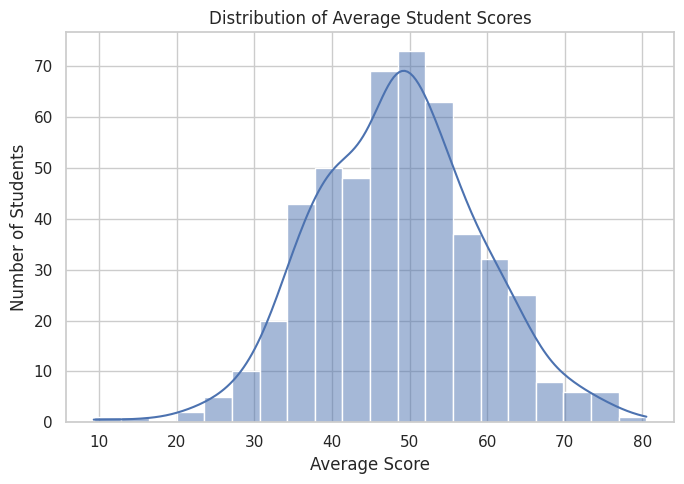

In [11]:
plt.figure(figsize=(7,5))
sns.histplot(df["average_score"], bins=20, kde=True, color="#4C72B0")
plt.title("Distribution of Average Student Scores")
plt.xlabel("Average Score"); plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("charts/01_score_distribution.png", dpi=150)
plt.show()


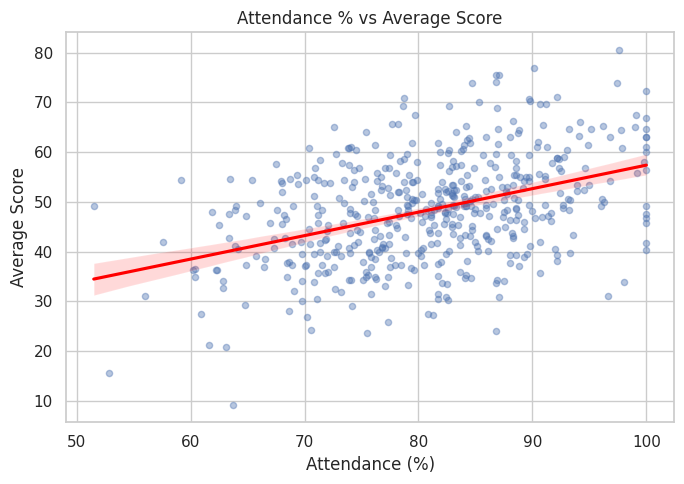

In [12]:
plt.figure(figsize=(7,5))
sns.regplot(data=df, x="attendance_percentage", y="average_score",
            scatter_kws={"alpha":0.4,"s":20}, line_kws={"color":"red"})
plt.title("Attendance % vs Average Score")
plt.xlabel("Attendance (%)"); plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("charts/02_attendance_vs_score.png", dpi=150)
plt.show()


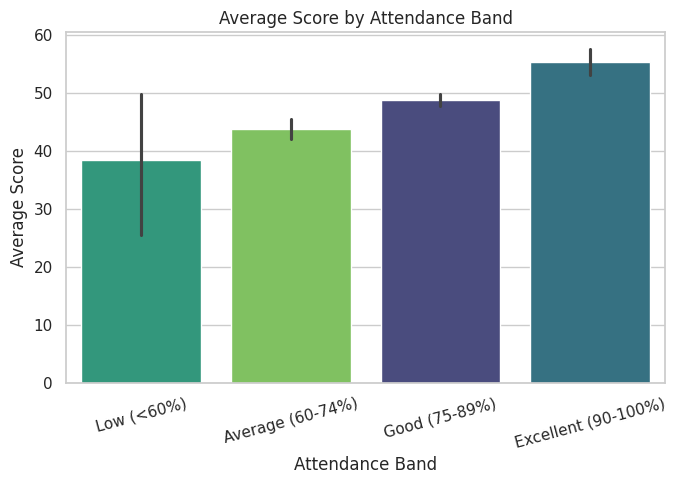

In [13]:
order = ["Low (<60%)", "Average (60-74%)", "Good (75-89%)", "Excellent (90-100%)"]
plt.figure(figsize=(7,5))
sns.barplot(data=df, x="attendance_band", y="average_score", order=order,
            hue="attendance_band", legend=False, palette="viridis")
plt.title("Average Score by Attendance Band")
plt.xlabel("Attendance Band"); plt.ylabel("Average Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("charts/03_score_by_attendance_band.png", dpi=150)
plt.show()


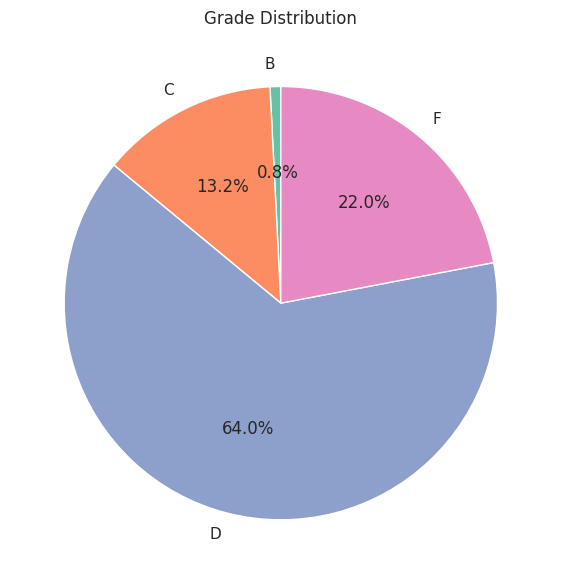

In [14]:
grade_counts = df["grade"].value_counts().sort_index()
plt.figure(figsize=(6,6))
plt.pie(grade_counts.values, labels=grade_counts.index, autopct="%1.1f%%",
        colors=sns.color_palette("Set2", len(grade_counts)), startangle=90)
plt.title("Grade Distribution")
plt.tight_layout()
plt.savefig("charts/04_grade_distribution.png", dpi=150)
plt.show()


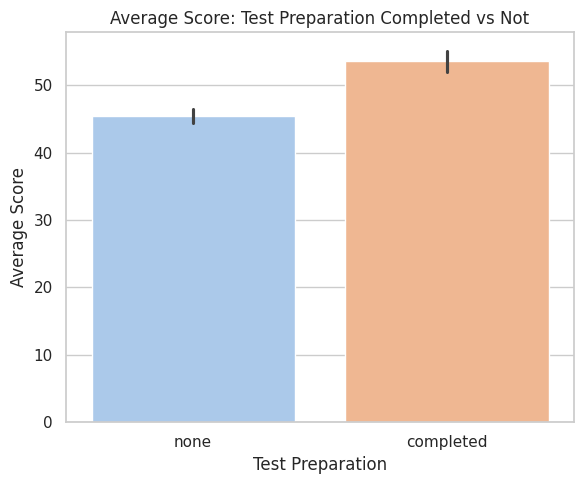

In [15]:
plt.figure(figsize=(6,5))
sns.barplot(data=df, x="test_preparation", y="average_score",
            hue="test_preparation", legend=False, palette="pastel")
plt.title("Average Score: Test Preparation Completed vs Not")
plt.xlabel("Test Preparation"); plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("charts/05_score_by_test_prep.png", dpi=150)
plt.show()


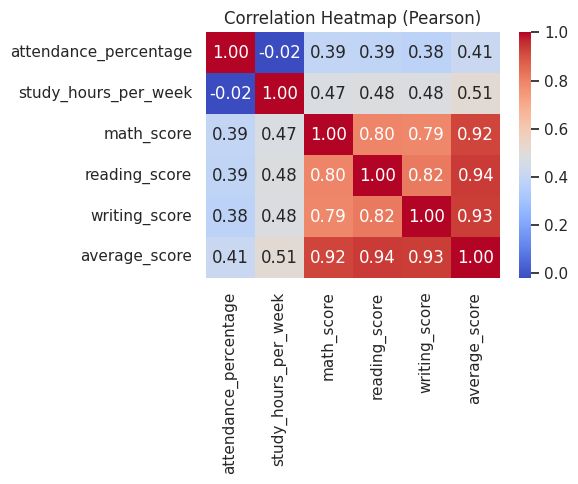

In [16]:
plt.figure(figsize=(6,5))
sns.heatmap(df[num_cols].corr(method="pearson"), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Pearson)")
plt.tight_layout()
plt.savefig("charts/06_correlation_heatmap.png", dpi=150)
plt.show()


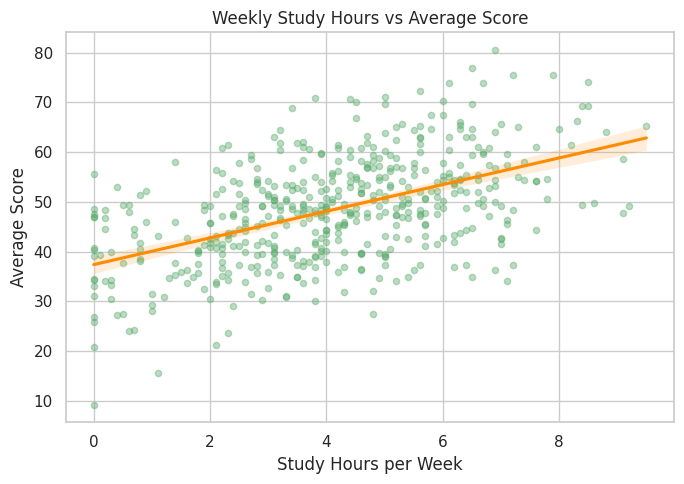

In [17]:
plt.figure(figsize=(7,5))
sns.regplot(data=df, x="study_hours_per_week", y="average_score",
            scatter_kws={"alpha":0.4,"s":20,"color":"#55A868"}, line_kws={"color":"darkorange"})
plt.title("Weekly Study Hours vs Average Score")
plt.xlabel("Study Hours per Week"); plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("charts/07_study_hours_vs_score.png", dpi=150)
plt.show()


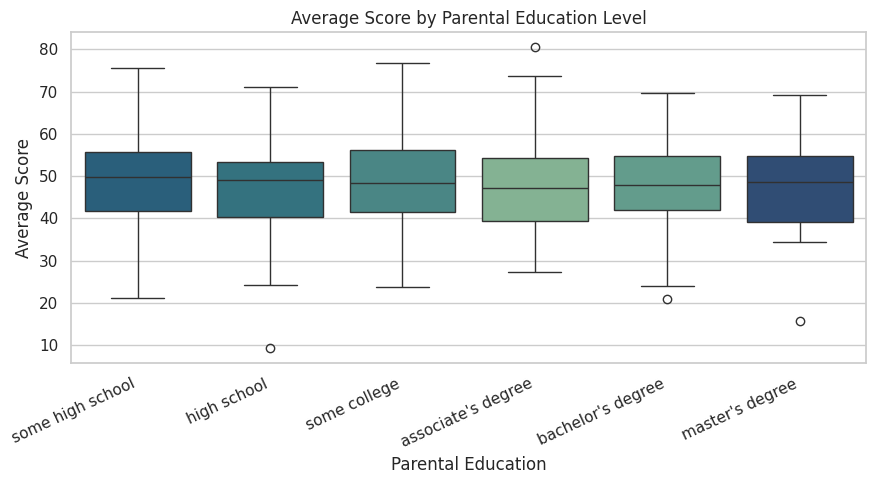

In [18]:
edu_order = ["some high school", "high school", "some college",
             "associate's degree", "bachelor's degree", "master's degree"]
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="parental_education", y="average_score", order=edu_order,
            hue="parental_education", legend=False, palette="crest")
plt.title("Average Score by Parental Education Level")
plt.xlabel("Parental Education"); plt.ylabel("Average Score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("charts/08_score_by_parental_education.png", dpi=150)
plt.show()


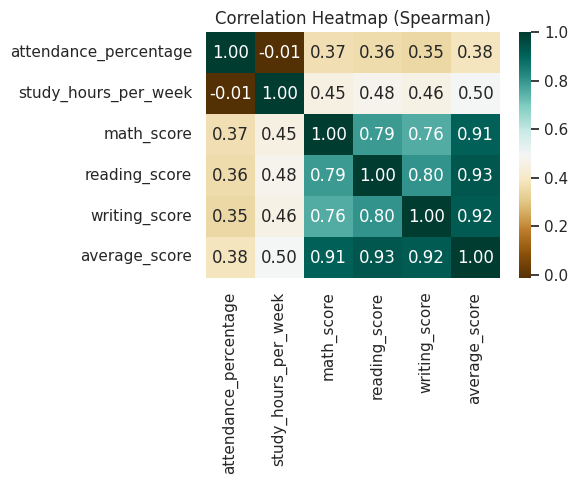

In [19]:
plt.figure(figsize=(6,5))
sns.heatmap(df[num_cols].corr(method="spearman"), annot=True, cmap="BrBG", fmt=".2f")
plt.title("Correlation Heatmap (Spearman)")
plt.tight_layout()
plt.savefig("charts/09_spearman_correlation_heatmap.png", dpi=150)
plt.show()


## 6. Performance Segmentation
Students are grouped into four score-based segments: **At Risk**
(score < 35), **Needs Attention** (35–45), **Moderate** (45–60), and
**High Performer** (score ≥ 60). Thresholds were set from this dataset's
own score distribution — see `data_dictionary.md` for details.


In [20]:
SEGMENT_BINS = [-1, 35, 45, 60, 200]
SEGMENT_LABELS = ["At Risk", "Needs Attention", "Moderate", "High Performer"]

df["performance_segment"] = pd.cut(df["average_score"], bins=SEGMENT_BINS, labels=SEGMENT_LABELS)
df["performance_segment"] = pd.Categorical(df["performance_segment"], categories=SEGMENT_LABELS, ordered=True)

segment_summary = (
    df.groupby("performance_segment", observed=True)
    .agg(student_count=("student_id","count"),
         avg_score=("average_score","mean"),
         avg_attendance=("attendance_percentage","mean"),
         avg_study_hours=("study_hours_per_week","mean"),
         test_prep_completion_rate_pct=("test_preparation", lambda s: (s=="completed").mean()*100))
    .round(1).reindex(SEGMENT_LABELS).reset_index()
)
segment_summary["share_of_students_pct"] = (segment_summary["student_count"]/segment_summary["student_count"].sum()*100).round(1)

df.to_csv("data/student_data_segmented.csv", index=False)
segment_summary.to_csv("data/segment_summary.csv", index=False)
segment_summary


,performance_segment,student_count,avg_score,avg_attendance,avg_study_hours,test_prep_completion_rate_pct,share_of_students_pct
0,At Risk,51,30.4,75.0,2.1,11.8,10.2
1,Needs Attention,131,40.3,78.0,3.4,20.6,26.2
2,Moderate,249,51.6,81.8,4.4,39.0,49.8
3,High Performer,69,65.5,87.7,5.7,72.5,13.8


## 7. Risk Analysis
Students are flagged using project-defined rules combining low score
(< 40) with low attendance (< 75%) and/or low study hours (< 3 hrs/week).
This is a descriptive, rule-based indicator — **not** a predictive or
diagnostic classification. See `src_05_risk_analysis.py` for the full
decision logic.


In [21]:
SCORE_THRESHOLD = 40
ATTENDANCE_THRESHOLD = 75
STUDY_HOURS_THRESHOLD = 3

df["low_score_flag"] = df["average_score"] < SCORE_THRESHOLD
df["low_attendance_flag"] = df["attendance_percentage"] < ATTENDANCE_THRESHOLD
df["low_study_hours_flag"] = df["study_hours_per_week"] < STUDY_HOURS_THRESHOLD

def risk_level(row):
    if not row["low_score_flag"]:
        return "No Risk Indicated"
    if row["low_attendance_flag"] and row["low_study_hours_flag"]:
        return "High Risk"
    if row["low_attendance_flag"] or row["low_study_hours_flag"]:
        return "Medium Risk"
    return "Watch"

df["risk_level"] = df.apply(risk_level, axis=1)
df["risk_level"] = pd.Categorical(df["risk_level"],
    categories=["High Risk","Medium Risk","Watch","No Risk Indicated"], ordered=True)

risk_summary = (
    df.groupby("risk_level", observed=True)
    .agg(student_count=("student_id","count"),
         avg_score=("average_score","mean"),
         avg_attendance=("attendance_percentage","mean"),
         avg_study_hours=("study_hours_per_week","mean"))
    .round(1).reindex(["High Risk","Medium Risk","Watch","No Risk Indicated"]).reset_index()
)

risk_cols = ["student_id","gender","average_score","attendance_percentage","study_hours_per_week",
             "test_preparation","low_score_flag","low_attendance_flag","low_study_hours_flag","risk_level"]
df[risk_cols].to_csv("data/risk_analysis.csv", index=False)
risk_summary


,risk_level,student_count,avg_score,avg_attendance,avg_study_hours
0,High Risk,20,29.9,68.6,1.5
1,Medium Risk,65,34.6,76.5,2.7
2,Watch,25,37.5,80.2,4.1
3,No Risk Indicated,390,52.3,82.4,4.5


## 8. Key Findings

1. Attendance and weekly study hours are both **positively and
   significantly associated** with average score (both p < 0.001).
2. Study hours show a **stronger association** with score than attendance,
   based on correlation strength and regression R².
3. Students who completed test preparation scored significantly higher
   on average (Welch's t-test, p < 0.001).
4. Parental education shows **no statistically significant association**
   with average score (one-way ANOVA, p = 0.911, η² = 0.003). The gender
   difference is small relative to within-group variation and is not
   treated as a meaningful finding.
5. Segmentation and risk analysis together identify a concentrated "High
   Risk" subgroup combining low score, low attendance, and low study
   hours — a candidate group for targeted review.


## 9. Limitations

- **Synthetic data** — findings describe patterns in a synthetically
  generated dataset, not real student records; relationships were partly
  built into the data-generation process, so results should not be
  generalized to real institutions.
- **Correlation, not causation** — no causal claims are made or supported.
- **No predictive modeling** — regression here is descriptive, not a
  validated predictive model.
- **Segmentation and risk thresholds are project-defined**, not
  externally validated.
- **Single snapshot** — no longitudinal or trend analysis was performed.


## 10. Export Outputs
All cleaned, segmented, and risk-flagged datasets, plus the written report, are exported for submission.

In [22]:
print("Cleaned dataset      -> data/student_data_clean.csv")
print("Segmented dataset    -> data/student_data_segmented.csv")
print("Segment summary      -> data/segment_summary.csv")
print("Risk analysis output -> data/risk_analysis.csv")
print("Full written report  -> report/PROJECT_REPORT.md")


Cleaned dataset      -> data/student_data_clean.csv
Segmented dataset    -> data/student_data_segmented.csv
Segment summary      -> data/segment_summary.csv
Risk analysis output -> data/risk_analysis.csv
Full written report  -> report/PROJECT_REPORT.md
